<a href="https://colab.research.google.com/github/MohdFuzailHaider/flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research Question**

Can early-period content performance signals be used to rank content pages for human review based on their observed risk of declining in a later period?

This project studies whether search and engagement signals observed during an early time window can help identify pages that later show lower average daily search impressions. The goal is not to predict changes in Google's algorithm or to prove why a page declines. Instead, the model is designed as a decision-support tool that ranks pages for review based on patterns learned from the observed data.

**Decision Supported**

Content teams often have more pages to review than they have editorial capacity to investigate. Reviewing every page equally is inefficient.

This work supports the decision:

> **Which content pages should a human reviewer investigate first for possible signs of declining search visibility?**

The output is a ranked review queue. Pages near the top are not automatically refreshed, rewritten, deleted, or modified. Their ranking indicates that, based on the observed early-period signals and the validated model, they may be worth reviewing earlier than lower-ranked pages.

The intended use is therefore **prioritization for human investigation**, not autonomous content management.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data Source**

This project uses the **FlyRank ML Internship Warehouse dataset**, release **v20260703**. The warehouse contains pseudonymized production search and content-performance data.

The analysis in this project uses the:

> `fact_content_daily_performance`

table, where each record represents a daily observation for a pseudonymized content item within a pseudonymized client portfolio.

No client names, domains, URLs, private search queries, or credentials are used in this public analysis.

**Time Window**

This capstone focuses on data from **March 2026** and separates the month into two periods:

- **Early observation period:** March 1–15, 2026
- **Later outcome period:** March 16–31, 2026

The early period is used to construct the input features. The later period is used only to define the observed decline outcome.

This separation helps preserve the intended temporal direction of the analysis: information from the later period is not used as a model feature.

**Modeling Data**

Daily observations were aggregated to the content-item level using the pseudonymized client and content identifiers as grouping keys.

The resulting modeling dataset contains **319,759 content items across 52 pseudonymized clients**.

The analysis uses early-period search and engagement signals, including impressions, clicks, average search position, pageviews, sessions, users, engaged sessions, engagement time, organic sessions, and scroll events.

**Data availability**

Search and analytics availability was checked before constructing the modeling dataset.

The March 2026 extract contains data with different combinations of GSC and GA4 availability. Availability is not uniform across all clients or reporting rows.

At the client level, 52 clients were present in the early-period data. Of these, 44 had at least some GSC data available, while 8 had no GSC availability during the early period. No client had GSC data available for every early-period row.

Because availability varies over time and across clients, missing search data was not interpreted as zero search performance. Availability flags were considered when constructing the analysis dataset to avoid confusing unavailable measurements with genuine zero values.

The availability flags were examined during the earlier data-preparation and validation work. Because availability varies over time and across clients, the results should be interpreted with this limitation in mind, particularly for GA4-derived engagement measures.

In [ ]:
from google.colab import userdata
from huggingface_hub import hf_hub_download
import pandas as pd

HF_TOKEN = userdata.get("HF_TOKEN")

def load_month(month):
    path = hf_hub_download(
        repo_id="FlyRank/internship-warehouse",
        repo_type="dataset",
        filename=f"fact_content_daily_performance/month={month}/data_0.parquet",
        token=HF_TOKEN,
    )

    return pd.read_parquet(path)

mar = load_month("2026-03")

print("Raw March dataset shape:", mar.shape)
print("\nDate range:")
print("Start:", mar["report_date"].min())
print("End:", mar["report_date"].max())

Raw March dataset shape: (9841378, 30)

Date range:
Start: 2026-03-01
End: 2026-03-31


In [ ]:
mar["report_date"] = pd.to_datetime(mar["report_date"])

early = mar[
    (mar["report_date"] >= "2026-03-01") &
    (mar["report_date"] <= "2026-03-15")
].copy()

late = mar[
    (mar["report_date"] >= "2026-03-16") &
    (mar["report_date"] <= "2026-03-31")
].copy()

print("Early period:", early["report_date"].min(), "to", early["report_date"].max())
print("Early rows:", len(early))

print("\nLate period:", late["report_date"].min(), "to", late["report_date"].max())
print("Late rows:", len(late))

Early period: 2026-03-01 00:00:00 to 2026-03-15 00:00:00
Early rows: 4642255

Late period: 2026-03-16 00:00:00 to 2026-03-31 00:00:00
Late rows: 5199123


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

This analysis treats content decline as a prediction and ranking problem. The goal is to use measurements from an earlier observation period to identify content items that should be reviewed first because they show a higher modeled risk of decline in a later period.

**Time-window design**

The March 2026 data was divided into two non-overlapping periods:

- **Early period:** March 1–15, 2026
- **Late period:** March 16–31, 2026

Early-period measurements were used to construct model features. Late-period measurements were reserved for constructing the outcome used to evaluate decline. This separation was used to reduce the risk of using future information when predicting the later outcome.

**Data availability**

Search and analytics availability varies across clients and reporting rows. The early-period data contained 52 clients, of which 44 had at least some GSC availability and 8 had no GSC availability during the early period. No client had GSC data available for every early-period row.

Because unavailable measurements should not automatically be interpreted as genuine zero performance, availability flags were checked during data preparation. The analysis distinguishes data-source availability from observed performance values.

In [ ]:
feature_cols = [
    'impressions',
    'clicks',
    'avg_position',
    'pageviews',
    'sessions',
    'users',
    'engaged_sessions',
    'engagement_sec',
    'organic_sessions',
    'scroll_events'
]

print("Final model features:")
print(feature_cols)

print("\nNumber of features:", len(feature_cols))

Final model features:
['impressions', 'clicks', 'avg_position', 'pageviews', 'sessions', 'users', 'engaged_sessions', 'engagement_sec', 'organic_sessions', 'scroll_events']

Number of features: 10


**Model features**

The model uses ten measurements derived from the early observation period:

- impressions
- clicks
- average search position
- pageviews
- sessions
- users
- engaged sessions
- engagement time
- organic sessions
- scroll events

These variables describe search visibility and observed user activity during the early period. They are used as inputs for the model rather than as evidence that any individual signal causes later decline.

**Target definition**

The target variable, `is_declining`, was constructed by comparing average daily search impressions across two non-overlapping periods.

The early period covered March 1–15, 2026 (15 days), and the late period covered March 16–31, 2026 (16 days). To account for the different number of days in the two periods, total impressions were converted to average daily impressions before comparison.

A content item was labeled as declining (`is_declining = 1`) when:

1. It had more than zero impressions during the early period, and
2. Its average daily impressions during the late period were lower than its average daily impressions during the early period.

Content items that did not meet these conditions were labeled as non-declining (`is_declining = 0`).

This label represents an observed decrease in average daily search impressions between these two periods. It does not establish why the decrease occurred or imply that any individual feature caused the decline.

**Baseline**

The machine-learning models were compared with a simple ranking baseline based on early-period impressions.

For the baseline, content items in the held-out test set were ranked by their early-period impression volume, from highest to lowest. This provides a transparent reference point for evaluating whether the model concentrates observed declining items nearer the top of the review queue more effectively than prioritizing highly visible content alone.

All methods were evaluated on the same held-out client set using Precision@K. The test-set decline rate was approximately 18.4%, providing additional context for interpreting the ranking results.

The baseline is not intended to represent a complete content-refresh strategy. It is a simple comparison rule used to test whether the model provides additional ranking value for the review decision.

**Validation design**

The primary validation design used a grouped train-test split based on `client_hash_id`.

A `GroupShuffleSplit` was used with a test proportion of 20% and a fixed random state of 42. This produced a training set containing 265,352 content items from 41 clients and a held-out test set containing 54,407 content items from 11 clients.

No client appeared in both the training and test sets.

Grouping by client was used to reduce the risk of evaluating the model on content from the same clients it had already seen during training. The resulting evaluation therefore tests ranking performance on held-out clients rather than only on randomly held-out rows from known clients.

Model performance was evaluated using Precision@K because the intended output is a ranked review queue. Results were examined at K = 100, 500, 1,000, and 5,000.

The held-out test-set decline rate was approximately 18.4% and was reported alongside ranking performance to provide a reference point for interpreting the Precision@K results.

**Leakage checks**

A leakage audit was performed on the final feature set to check whether future-period outcomes or target-related columns were accidentally included as model inputs.

The final model used ten early-period features:

- impressions
- clicks
- avg_position
- pageviews
- sessions
- users
- engaged_sessions
- engagement_sec
- organic_sessions
- scroll_events

The outcome was constructed using impressions from a later period. The audit confirmed that `late_impressions`, `late_daily_impressions`, and `is_declining` were not included in the final model feature set.

The model features were constructed from the observation period of **March 1–15, 2026**, while the later period of **March 16–31, 2026** was used to construct the decline outcome. Based on this audit, no direct future-period information leakage was identified in the final model features.

Two limitations identified during the audit should still be disclosed. First, early-period `impressions` is used as a model feature and also contributes to the construction of the decline label through its comparison with later-period impressions. This is not future-period leakage because the early-period value is available before the outcome period, but the relationship should be interpreted carefully.

Second, several GA4-derived features were aggregated without explicitly excluding rows where `ga4_data_available` was `False`. Some aggregated values may therefore include zero-filled periods caused by unavailable GA4 data rather than genuine zero engagement.

For these reasons, the model is interpreted as a directional decision-support tool for ranking pages for human review, rather than as a definitive prediction system.

In [ ]:
# Leakage audit for the final feature set

future_target_cols = [
    "late_impressions",
    "late_daily_impressions",
    "is_declining"
]

leakage_check = pd.DataFrame({
    "column": future_target_cols,
    "used_as_model_feature": [
        col in feature_cols for col in future_target_cols
    ]
})

print("Leakage audit:")
display(leakage_check)

print("\nFinal model features:")
print(feature_cols)

assert not any(col in feature_cols for col in future_target_cols)

print("\n✓ No direct future-period or target columns are used as model features.")

Leakage audit:


,column,used_as_model_feature
0,late_impressions,False
1,late_daily_impressions,False
2,is_declining,False



Final model features:
['impressions', 'clicks', 'avg_position', 'pageviews', 'sessions', 'users', 'engaged_sessions', 'engagement_sec', 'organic_sessions', 'scroll_events']

✓ No direct future-period or target columns are used as model features.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The models were evaluated on the same held-out client set using Precision@K, because the intended use of the system is to rank content items for review.

The held-out test set had an overall decline rate of approximately **18.4%**. This provides context for the Precision@K results: a ranking method is useful when it concentrates observed declining items near the top of the review queue.

The table below compares the simple impressions baseline with Logistic Regression, a balanced Random Forest, and a standard Random Forest on the same held-out data.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "K": [100, 500, 1000, 5000],
    "Baseline (Impressions)": [0.3200, 0.2740, 0.2730, 0.3158],
    "Logistic Regression": [0.3600, 0.3160, 0.3140, 0.3370],
    "Random Forest Balanced": [0.4000, 0.4020, 0.4800, 0.4428],
    "Random Forest": [0.3600, 0.4160, 0.4380, 0.4348]
})

comparison_pct = comparison_df.copy()

for col in comparison_pct.columns[1:]:
    comparison_pct[col] = (comparison_pct[col] * 100).round(1)

comparison_pct

,K,Baseline (Impressions),Logistic Regression,Random Forest Balanced,Random Forest
0,100,32.0,36.0,40.0,36.0
1,500,27.4,31.6,40.2,41.6
2,1000,27.3,31.4,48.0,43.8
3,5000,31.6,33.7,44.3,43.5


**Main findings**

The machine-learning models concentrated observed declining content items nearer the top of the ranking than the simple impressions baseline across the evaluated queue sizes.

The balanced Random Forest showed the strongest overall performance across the evaluation points. It achieved:

- **Precision@100: 40.0%**
- **Precision@1,000: 48.0%**
- **Precision@5,000: 44.3%**

At **K = 1,000**, the balanced Random Forest identified observed declining items in **48.0%** of the top-ranked pages, compared with **27.3%** for the impressions baseline and **31.4%** for Logistic Regression.

These results were observed on the held-out client set. They indicate that the model provided stronger ranking performance for this dataset and validation design, rather than proving that reviewing or refreshing a page will prevent or reverse future decline.

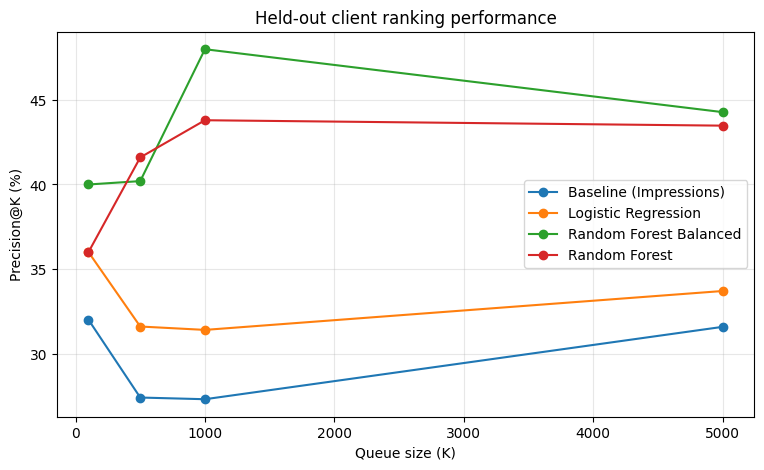

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["K"],
    comparison_df["Baseline (Impressions)"] * 100,
    marker="o",
    label="Baseline (Impressions)"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Logistic Regression"] * 100,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Random Forest Balanced"] * 100,
    marker="o",
    label="Random Forest Balanced"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Random Forest"] * 100,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Queue size (K)")
plt.ylabel("Precision@K (%)")
plt.title("Held-out client ranking performance")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**Figure interpretation:** Across the evaluated queue sizes, the machine-learning models generally achieved higher Precision@K than the impressions baseline. The balanced Random Forest produced the strongest overall results, particularly at K = 1,000, where 48.0% of the top-ranked items were observed declining items in the held-out data.

**Feature importance**

To help interpret the signals used by the Random Forest, feature importance values were examined.

In this model, early-period impressions and average search position received the largest importance values. Impressions had an importance of approximately **0.580**, followed by average position at approximately **0.300**.

The remaining features contributed substantially smaller importance values.

Feature importance describes how strongly the fitted Random Forest used each feature when making splits across its trees. These values should not be interpreted as causal effects. A high importance value does not mean that changing that metric will cause a change in future content performance.

The importance results are therefore used as model interpretation for this dataset and validation design, rather than as evidence of how search systems or users behave in general.

In [ ]:
feature_importance = pd.DataFrame({
    "feature": [
        "impressions",
        "avg_position",
        "clicks",
        "sessions",
        "pageviews",
        "organic_sessions",
        "users",
        "engagement_sec",
        "scroll_events",
        "engaged_sessions"
    ],
    "importance": [
        0.580165,
        0.300110,
        0.055243,
        0.014955,
        0.013636,
        0.012926,
        0.010844,
        0.006605,
        0.004853,
        0.000663
    ]
})

feature_importance

,feature,importance
0,impressions,0.580165
1,avg_position,0.300110
2,clicks,0.055243
3,sessions,0.014955
4,pageviews,0.013636
5,organic_sessions,0.012926
6,users,0.010844
7,engagement_sec,0.006605
8,scroll_events,0.004853
9,engaged_sessions,0.000663


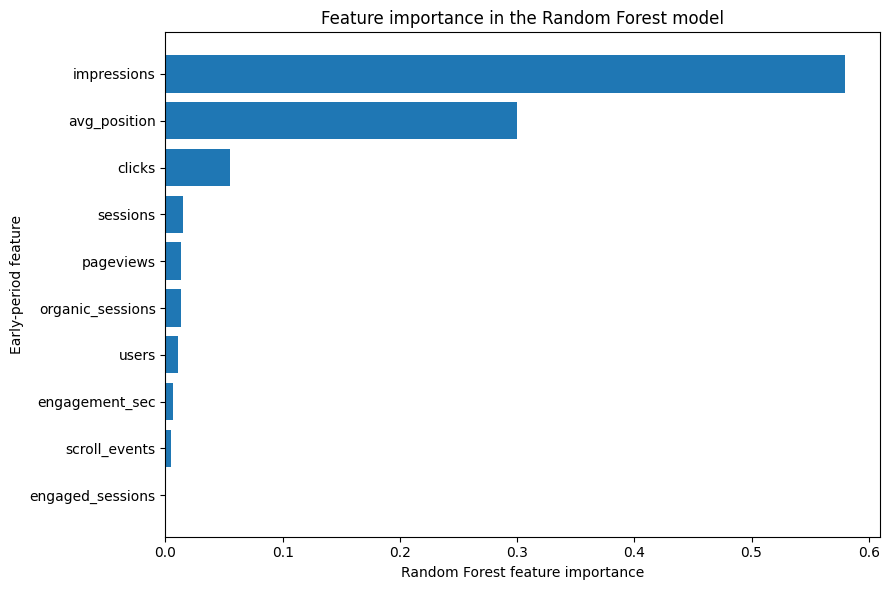

In [ ]:
import matplotlib.pyplot as plt

feature_importance_plot = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_plot["feature"],
    feature_importance_plot["importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Early-period feature")
plt.title("Feature importance in the Random Forest model")

plt.tight_layout()
plt.show()

**Figure interpretation:** In the fitted Random Forest, early-period impressions and average search position accounted for most of the measured feature importance. Other included search and engagement signals had smaller importance values in this model.

Overall, the fitted Random Forest relied most heavily on early-period impressions and average search position when ranking decline risk in this dataset.

## 5. Limitations

*What this work cannot claim.*

This work is designed as a decision-support analysis, and several limitations should be considered when interpreting the results.


---


**No causal claims**

The analysis identifies patterns associated with observed content decline and evaluates how well the model ranks declining items on held-out clients. It does not establish that any individual feature causes content decline.

Similarly, the results do not show that refreshing, rewriting, or modifying a recommended page will improve its future performance. Demonstrating causal refresh impact would require an intervention or experimental design.


---


**Limited outcome definition**

The decline label is based on a comparison between early-period and later-period impressions. This definition provides a practical outcome for ranking content for review, but it represents one operational definition of decline rather than a universal definition of content performance.

The model therefore ranks items according to the decline pattern defined in this project and may produce different results if a different time window or decline definition is used.

---

**Dataset and time-period limits**

The findings are based on the FlyRank internship dataset and the selected observation and outcome periods used in this analysis. Patterns observed in this dataset may not generalize to every website, client, content portfolio, or future time period.

Performance should therefore be interpreted within the dataset and validation design used here.

---

**Feature and data availability limits**

The model uses a limited set of early-period search and engagement signals. Other potentially relevant factors were not included in the final feature set.

In addition, some GA4-derived metrics may be affected by data availability. Periods where GA4 data was unavailable can contain zero-filled values, meaning some aggregated engagement measures may not always represent genuine zero activity.

---

**Model interpretation limits**

Feature importance values show which variables the fitted Random Forest relied on most heavily when constructing its ranking. They do not measure causal effects.

For example, the high importance of early-period impressions does not mean that changing impressions would cause future decline. The importance results only describe how the fitted model used the available features in this dataset.

---

**Ranking, not automatic action**

The model produces a ranked review queue, not an automatic content-management system.

A high decline-risk score should be treated as a signal that an item may be worth human review. Before taking action, a reviewer should examine the content context, data quality, business relevance, and possible reasons behind the observed pattern.

For these reasons, the results are best interpreted as directional decision-support for prioritizing content review rather than as definitive predictions or automated instructions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model output is intended to support content prioritization rather than automatically changing content.

Content items are ranked by their predicted decline probability, with higher-ranked items representing pages that the model flags as higher priority for human review. The ranking is combined with simple reason codes so that a reviewer can understand why an item appeared near the top of the queue.

The highest-priority items in the queue should be reviewed first, particularly when the ranking is accompanied by signals such as:

- High model-estimated decline risk
- High early-period impression volume
- Weaker average search position relative to the dataset

These signals do not prescribe a single automatic action. Instead, they provide a starting point for investigation.

**Recommended review actions**

The ranked queue is designed to help reviewers decide where to spend limited content-review time.

A high-priority item may be considered for one of several actions after human review:

| Review outcome | Suggested action |
|---|---|
| The content is still relevant but appears to be losing visibility | Review and consider refreshing the content |
| The topic remains valuable but the page no longer matches current search intent | Review for substantial improvement or rewriting |
| The page has overlapping or redundant content | Consider consolidation or merging after review |
| The content remains strategically valuable and performs adequately | Protect and monitor |
| The recommendation appears to be driven by unusual or questionable data | Investigate data quality before taking action |

The model does not determine which of these actions is correct. It only helps prioritize which content items may be worth reviewing first.

**Reason codes**

Each ranked recommendation should include simple reason codes alongside the priority rank.

For example:

> **Ranked #1 by the model's decline-risk score | High early-period impression volume | Weaker average search position relative to this dataset**

The reason codes are intended to make the ranking easier for a human reviewer to interpret.

They should not be treated as explanations of causality. A reason code describes the signals associated with an item's position in the review queue; it does not prove why that content declined or predict that a particular intervention will improve it.

**Decay and refresh insight**

The analysis supports a practical monitoring idea: content performance can change over time, so content review should not rely only on a page's historical importance.

Pages with substantial early-period visibility may still deserve attention when the model identifies a pattern associated with observed decline. This creates a potential review opportunity because high-visibility content may represent greater potential value for investigation.

However, the results do not show that refreshing content will reverse decline. A refresh recommendation should therefore be treated as a hypothesis for human review rather than an expected outcome.

The ranked queue is best understood as a way to focus attention on potentially important items before deciding whether a refresh, rewrite, monitoring action, or no action is appropriate.

In [ ]:
import pandas as pd

ranked_recommendations = pd.DataFrame({
    "priority_rank": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],

    "decline_probability": [
        0.968244, 0.968128, 0.965234, 0.964001, 0.963477,
        0.962320, 0.960721, 0.959601, 0.958246, 0.956202
    ],

    "impressions": [
        16091, 17902, 1684, 24759, 1246,
        4975, 18139, 2708, 20267, 893
    ],

    "clicks": [
        18, 21, 0, 25, 0,
        0, 11, 0, 25, 0
    ],

    "avg_position": [
        39.991381, 33.882071, 33.029432, 38.649502, 30.475711,
        49.788772, 36.055048, 37.568633, 32.649680, 45.956021
    ]
})

ranked_recommendations

,priority_rank,decline_probability,impressions,clicks,avg_position
0,1,0.968244,16091,18,39.991381
1,2,0.968128,17902,21,33.882071
2,3,0.965234,1684,0,33.029432
3,4,0.964001,24759,25,38.649502
4,5,0.963477,1246,0,30.475711
5,6,0.962320,4975,0,49.788772
6,7,0.960721,18139,11,36.055048
7,8,0.959601,2708,0,37.568633
8,9,0.958246,20267,25,32.649680
9,10,0.956202,893,0,45.956021


In [ ]:
ranked_recommendations["reason_code"] = ranked_recommendations.apply(
    lambda row: (
        f"Ranked #{int(row['priority_rank'])} by the model's decline-risk score "
        f"({row['decline_probability']:.3f}) | "
        f"High early-period impression volume ({int(row['impressions'])}) | "
        f"Weaker average search position relative to this dataset "
        f"({row['avg_position']:.2f})"
    ),
    axis=1
)

ranked_recommendations[
    [
        "priority_rank",
        "decline_probability",
        "impressions",
        "avg_position",
        "reason_code"
    ]
]

,priority_rank,decline_probability,impressions,avg_position,reason_code
0,1,0.968244,16091,39.991381,Ranked #1 by the model's decline-risk score (0...
1,2,0.968128,17902,33.882071,Ranked #2 by the model's decline-risk score (0...
2,3,0.965234,1684,33.029432,Ranked #3 by the model's decline-risk score (0...
3,4,0.964001,24759,38.649502,Ranked #4 by the model's decline-risk score (0...
4,5,0.963477,1246,30.475711,Ranked #5 by the model's decline-risk score (0...
5,6,0.962320,4975,49.788772,Ranked #6 by the model's decline-risk score (0...
6,7,0.960721,18139,36.055048,Ranked #7 by the model's decline-risk score (0...
7,8,0.959601,2708,37.568633,Ranked #8 by the model's decline-risk score (0...
8,9,0.958246,20267,32.649680,Ranked #9 by the model's decline-risk score (0...
9,10,0.956202,893,45.956021,Ranked #10 by the model's decline-risk score (...


**How the recommendations should be used**

The recommended workflow is:

1. Start with the highest-ranked items.
2. Read the reason codes and supporting signals.
3. Check data quality and content context.
4. Decide whether the item needs investigation, monitoring, refreshing, rewriting, consolidation, or no action.
5. Record the decision so future review can distinguish model recommendations from human actions.

This workflow keeps the system in a decision-support role. The ranking helps determine what to review first, while humans remain responsible for deciding what action, if any, should be taken.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section prepares the public-safe charts and tables used in the deployed research paper.

The artifacts summarize the model comparison, feature interpretation, and ranked recommendations. They are generated from the validated results presented in this notebook.

Only public-safe outputs are prepared for the paper. No client names, content identifiers, private URLs, or raw data exports are included.

In [ ]:
import os

os.makedirs("figures", exist_ok=True)

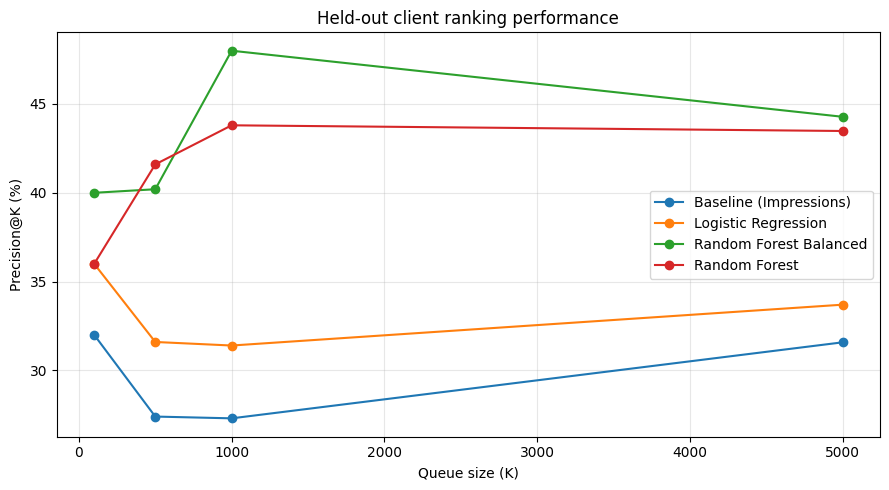

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(9, 5))

plt.plot(
    comparison_df["K"],
    comparison_df["Baseline (Impressions)"] * 100,
    marker="o",
    label="Baseline (Impressions)"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Logistic Regression"] * 100,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Random Forest Balanced"] * 100,
    marker="o",
    label="Random Forest Balanced"
)

plt.plot(
    comparison_df["K"],
    comparison_df["Random Forest"] * 100,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Queue size (K)")
plt.ylabel("Precision@K (%)")
plt.title("Held-out client ranking performance")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

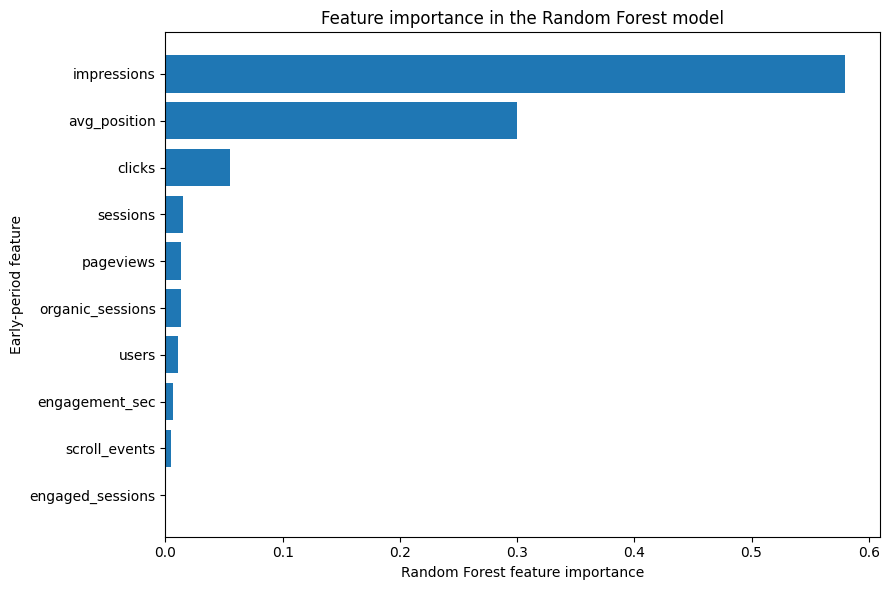

In [ ]:
plt.figure(figsize=(9, 6))

feature_importance_plot = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.barh(
    feature_importance_plot["feature"],
    feature_importance_plot["importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Early-period feature")
plt.title("Feature importance in the Random Forest model")

plt.tight_layout()

plt.savefig(
    "figures/feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
paper_recommendations = ranked_recommendations[
    [
        "priority_rank",
        "decline_probability",
        "impressions",
        "avg_position",
        "reason_code"
    ]
].copy()

paper_recommendations["decline_probability"] = (
    paper_recommendations["decline_probability"] * 100
).round(1)

paper_recommendations = paper_recommendations.rename(
    columns={
        "priority_rank": "Priority Rank",
        "decline_probability": "Decline Risk (%)",
        "impressions": "Early-Period Impressions",
        "avg_position": "Average Position",
        "reason_code": "Reason for Review"
    }
)

paper_recommendations

,Priority Rank,Decline Risk (%),Early-Period Impressions,Average Position,Reason for Review
0,1,96.8,16091,39.991381,Ranked #1 by the model's decline-risk score (0...
1,2,96.8,17902,33.882071,Ranked #2 by the model's decline-risk score (0...
2,3,96.5,1684,33.029432,Ranked #3 by the model's decline-risk score (0...
3,4,96.4,24759,38.649502,Ranked #4 by the model's decline-risk score (0...
4,5,96.3,1246,30.475711,Ranked #5 by the model's decline-risk score (0...
5,6,96.2,4975,49.788772,Ranked #6 by the model's decline-risk score (0...
6,7,96.1,18139,36.055048,Ranked #7 by the model's decline-risk score (0...
7,8,96.0,2708,37.568633,Ranked #8 by the model's decline-risk score (0...
8,9,95.8,20267,32.649680,Ranked #9 by the model's decline-risk score (0...
9,10,95.6,893,45.956021,Ranked #10 by the model's decline-risk score (...


**Paper artifacts**

The deployed research paper will include:

1. **Model vs baseline chart** — compares Precision@K across the evaluated ranking methods.
2. **Feature importance chart** — shows which early-period signals the fitted Random Forest relied on most heavily.
3. **Ranked recommendations table** — presents a public-safe example of the highest-priority review items and their reason codes.

Together, these artifacts connect the research question to the model evaluation and finally to the practical decision-support output.

## Self-check

Before you submit, confirm each line honestly:

- [ YES ] Every section above is filled — markdown thinking AND the code that backs it
- [ YES ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ YES ] No client names, URLs, or private queries anywhere
- [ YES ] My claims use careful words: observed, measured, directional, decision-support
- [ YES ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

# Week 8 Showcase

## 5-Minute Demo Outline

### 1. The Question — ~45 seconds

My capstone addresses a practical content-review problem: content teams may have more pages to investigate than they have time to review.

The research question was:

**Can early-period content performance signals be used to rank content pages for human review based on their observed risk of declining search visibility in a later period?**

The goal was to create a ranked review queue that helps prioritize human investigation rather than automatically making content changes.

---

### 2. The Method — ~1 minute

I used the FlyRank ML Internship Warehouse dataset and focused on March 2026 data.

March was divided into two non-overlapping periods:

- **Early observation period:** March 1–15, 2026
- **Later outcome period:** March 16–31, 2026

Early-period search and engagement signals were used as model features, while the later period was used only to define the observed decline outcome.

I compared a simple impressions-based ranking baseline with Logistic Regression, Random Forest, and Balanced Random Forest models.

To evaluate generalization, I used a grouped train-test split that held out entire pseudonymized clients.

---

### 3. One Chart — ~1 minute

The main chart compares the ranking performance of the baseline and machine learning models on the same held-out client set.

The key metric is **Precision@K**, which measures how many pages in the highest-ranked portion of the review queue actually showed the defined decline outcome.

This evaluation reflects the practical use case: helping a content team decide which pages may be worth investigating first.

---

### 4. One Honest Result — ~1 minute

The **Balanced Random Forest** produced the strongest overall ranking performance.

At **Precision@1,000**, it reached **48.0%**, compared with **27.3%** for the simple impressions-based baseline on the same held-out client set.

This means that, within this dataset and validation design, the model produced a more concentrated queue of pages showing the observed decline outcome.

This result is directional and should be interpreted as decision-support evidence. It does not prove that any feature causes future decline or describe how a search engine algorithm works.

---

### 5. Recommendation — ~1 minute

The main recommendation is to use the model output as a **prioritized queue for human review**.

Pages ranked near the top can be investigated first for possible signs of declining search visibility or changing content performance.

The model should not automatically trigger refreshing, rewriting, deleting, or modifying content. Instead, it helps direct limited editorial and analytical attention toward pages that may be worth reviewing earlier.

---

### Closing

This project demonstrates how large-scale search and engagement data can be used to build a validated, public-safe decision-support system for prioritizing content investigation.

The final output is not an automated content-management system—it is a ranked queue designed to help humans decide where to look first.

---

# Shareable Cuts

## Social Media Post

🚀 **FlyRank ML Internship Capstone**

I built a machine learning-based content opportunity ranking system using large-scale, pseudonymized production search and content-performance data from the FlyRank ML Internship Warehouse dataset.

My project asked whether early-period search and engagement signals could help rank content pages for human review based on their observed risk of declining search visibility in a later period. I compared a simple impressions-based baseline with Logistic Regression, Random Forest, and Balanced Random Forest models using a grouped train-test split that held out entire pseudonymized clients.

The Balanced Random Forest produced the strongest ranking performance, reaching **48.0% Precision@1,000**, compared with **27.3%** for the impressions baseline on the same held-out client set.

The final system is designed as **decision-support for prioritizing human investigation**, not as proof of causation or an automated content-management system.

🔗 Research paper: https://mohdfuzailhaider.github.io/flyrank/

#MachineLearning #DataScience #SearchAnalytics #ContentIntelligence #FlyRank

---

## Employer-Facing Summary

I built a machine learning-based content opportunity ranking system using large-scale pseudonymized production search and content-performance data from the FlyRank ML Internship Warehouse dataset. I compared an impressions-based baseline with Logistic Regression, Random Forest, and Balanced Random Forest models using a grouped train-test split that held out entire clients, with the Balanced Random Forest reaching 48.0% Precision@1,000 compared with 27.3% for the baseline. The resulting system provides a validated, public-safe decision-support queue to help content teams prioritize which pages may be worth investigating first.